In [27]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KernelDensity
from scipy.special import logsumexp

class BayesKDE(BaseEstimator, ClassifierMixin):
  def __init__(self, bandwidth=1.0):
    self.bandwidth = bandwidth

  def fit(self, X, y):
    self.classes_ = np.unique(y)
    self.kdes_ = {}
    self.log_priors_ = {}

    for cls in self.classes_:
      kde = KernelDensity(kernel='gaussian', bandwidth=self.bandwidth)
      kde.fit(X[y == cls])
      self.kdes_[cls] = kde
      prior = np.mean(y == cls)
      self.log_priors_[cls] = np.log(prior)

    return self

  def score_log_likelihoods(self, X):
    """Returns matrix of log p(x|y) for each class y."""
    n_samples = X.shape[0]
    log_likelihoods = np.zeros((n_samples, len(self.classes_)))

    for i, cls in enumerate(self.classes_):
      log_likelihoods[:, i] = self.kdes_[cls].score_samples(X)

    return log_likelihoods

  def score_log_posteriors(self, X):
    """Returns matrix of log p(y|x) up to normalization."""
    log_likelihoods = self.score_log_likelihoods(X)
    log_posteriors = log_likelihoods + np.array([self.log_priors_[cls] for cls in self.classes_])
    return log_posteriors

  def predict(self, X):
    log_posteriors = self.score_log_posteriors(X)
    return np.argmax(log_posteriors, axis=1)

  def predict_proba(self, X):
    log_posteriors = self.score_log_posteriors(X)
    log_norm = logsumexp(log_posteriors, axis=1, keepdims=True)
    return np.exp(log_posteriors - log_norm)


In [28]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

def load_pima_diabetes():
  url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/"
    "master/pima-indians-diabetes.data.csv"
  )
  cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
  ]
  df = pd.read_csv(url, header=None, names=cols)
  
  features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
  
  for feat in features:
    df[feat] = df[feat].replace(0, np.nan)
    df[feat] = df[feat].fillna(df[feat].median())
  
  X = df.drop("Outcome", axis=1).values
  y = df["Outcome"].values
  return X, y

def preprocess_data(X, y):
  
  # Standardize the features
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  
  # Convert to DataFrame for easier manipulation
  X_df = pd.DataFrame(X_scaled)
  
  # Remove low variance features
  selector = VarianceThreshold(threshold=0.01)
  X_low_var_removed = selector.fit_transform(X_df)
  
  # Remove highly correlated features
  X_corr = pd.DataFrame(X_low_var_removed).corr().abs()
  upper_triangle = X_corr.where(
    np.triu(np.ones(X_corr.shape), k=1).astype(bool)
  )
  to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
  X_final = pd.DataFrame(X_low_var_removed).drop(columns=to_drop, axis=1)
  
  return X_final.values, y

X, y = load_pima_diabetes()
X, y = preprocess_data(X, y)

In [40]:
import imageio
import os
import matplotlib.pyplot as plt

def compute_likelihood(bayes_kde, X, y):
  """Compute likelihoods for each class."""
  bayes_kde.fit(X, y)
  log_likelihoods = bayes_kde.score_log_likelihoods(X)
  likelihoods = np.exp(log_likelihoods)

  # pseudo-normalize
  max_likelihoods = np.max(likelihoods)
  likelihoods = likelihoods / max_likelihoods
  
  return [likelihoods[:, i] for i in range(likelihoods.shape[1])]

def plot_likelihood(Q0, Q1, y, title="likelihood"):
  plt.scatter(Q0, Q1, c=y)
  
  plt.xlabel('Q0')
  plt.ylabel('Q1')
  plt.grid()
  plt.title(title)
  plt.show()

def make_likelihood_gif(Qs, y, filename='likelihood_animation.gif'):
  filenames = []
  for idx, (h, Q0, Q1) in enumerate(Qs):
    plt.figure()
    plt.scatter(Q0, Q1, c=y)
    plt.xlabel('Q0')
    plt.ylabel('Q1')
    plt.title(f'Bandwidth: {h:.2f}')
    plt.grid(alpha=0.3)
    
    # Save frame
    frame_filename = f'frame_{idx:03d}.png'
    plt.savefig(frame_filename, dpi=100, bbox_inches='tight')
    plt.close()
    filenames.append(frame_filename)
  
  # Create GIF
  with imageio.get_writer(filename, mode='I', duration=0.3) as writer:
    for filename in filenames:
      image = imageio.v3.imread(filename)
      writer.append_data(image)
  
  # Cleanup temporary files
  for filename in filenames:
    os.remove(filename)


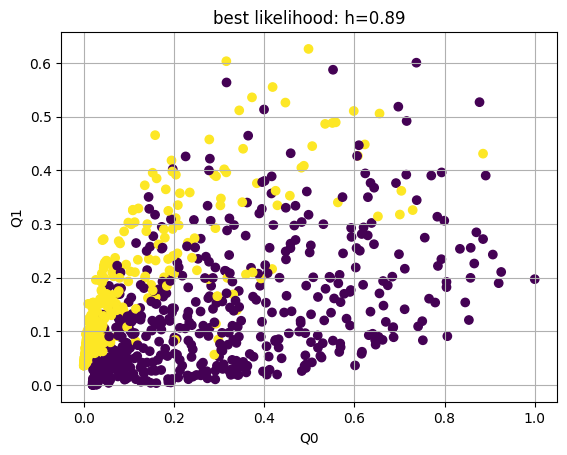

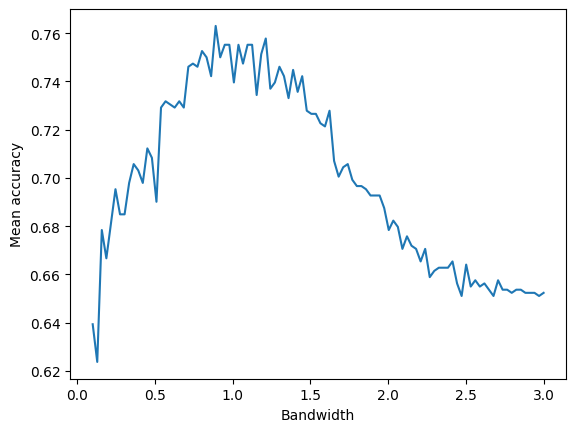

In [41]:
from sklearn.model_selection import cross_val_score, KFold

hs = np.linspace(0.1, 3, 100)

kf = KFold(n_splits=3, shuffle=True)
mean_scores = []
Qs = []

for h in hs:
  bayeskde = BayesKDE(bandwidth=h)
  scores = cross_val_score(bayeskde, X, y, cv=kf, scoring='accuracy')
  mean_scores.append(np.mean(scores))

  Q0, Q1 = compute_likelihood(bayeskde, X, y)
  Qs.append((h, Q0, Q1))

best_h = hs[np.argmax(mean_scores)]
best_bayeskde = BayesKDE(bandwidth=best_h)
best_Q0, best_Q1 = compute_likelihood(best_bayeskde, X, y)
plot_likelihood(best_Q0, best_Q1, y, title=f"best likelihood: h={best_h:.2f}")

make_likelihood_gif(Qs, y)

plt.figure()
plt.plot(hs, mean_scores)
plt.xlabel('Bandwidth')
plt.ylabel('Mean accuracy')
plt.savefig('bandwidth_vs_accuracy.png')
plt.show()


In [51]:
def compute_spread(Q, y, grid_size=100):
  """Compute spread for each class over its decision region using a 2D grid."""
  spread = {}
  eps = 1e-6
  x_edges = np.linspace(0, 1 + eps, grid_size + 1)
  y_edges = np.linspace(0, 1 + eps, grid_size + 1)

  for cls in [0, 1]:
    # Select points of class `cls` in its decision region
    if cls == 0:
      mask = (y == 0) & (Q[:, 0] > Q[:, 1]) & (Q[:, 0] >= 0) & (Q[:, 0] <= 1) & (Q[:, 1] >= 0) & (Q[:, 1] <= 1)
    else:
      mask = (y == 1) & (Q[:, 1] > Q[:, 0]) & (Q[:, 0] >= 0) & (Q[:, 0] <= 1) & (Q[:, 1] >= 0) & (Q[:, 1] <= 1)

    points = Q[mask]
    if len(points) == 0:
      spread[cls] = 0.0
      continue

    # Map points to grid
    hist, _, _ = np.histogram2d(points[:, 0], points[:, 1], bins=[x_edges, y_edges])
    covered_cells = np.count_nonzero(hist)

    spread[cls] = covered_cells / (grid_size ** 2)

  return spread

from scipy.spatial import ConvexHull

def hullspread(Q, y):
  """Compute the hull spread for each class."""
  # Class 0 spread
  class0 = Q[y == 0]
  if len(class0) > 0:
    in_region_mask = class0[:, 0] > class0[:, 1]
    class0_in_region = class0[in_region_mask]
    if len(class0_in_region) >= 3:
      try:
        hull0 = ConvexHull(class0_in_region[:, :2])
        area0 = hull0.volume
      except:
        area0 = 0.0
    else:
      area0 = 0.0
    spread0 = area0 / 0.5
  else:
    spread0 = 0.0
  
  # Class 1 spread
  class1 = Q[y == 1]
  if len(class1) > 0:
    in_region_mask = class1[:, 1] > class1[:, 0]
    class1_in_region = class1[in_region_mask]
    if len(class1_in_region) >= 3:
      try:
        hull1 = ConvexHull(class1_in_region[:, :2])
        area1 = hull1.volume
      except:
        area1 = 0.0
    else:
      area1 = 0.0
    spread1 = area1 / 0.5
  else:
    spread1 = 0.0
  
  total_spread = (spread0 + spread1) / 2

  return total_spread


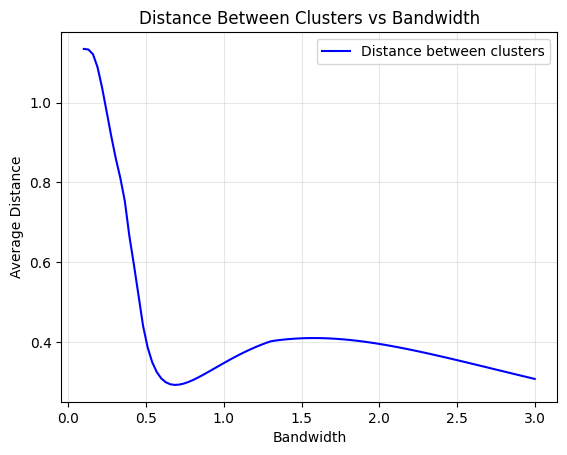

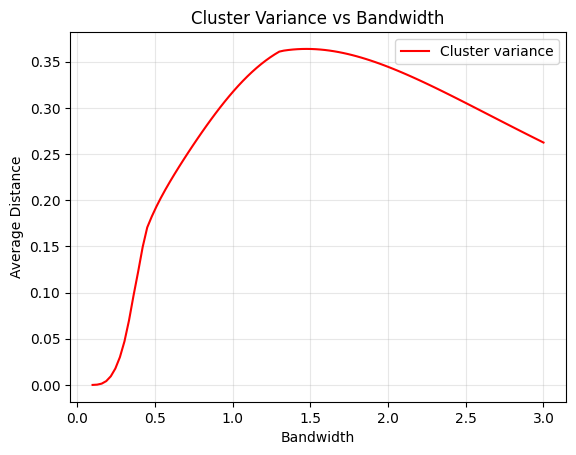

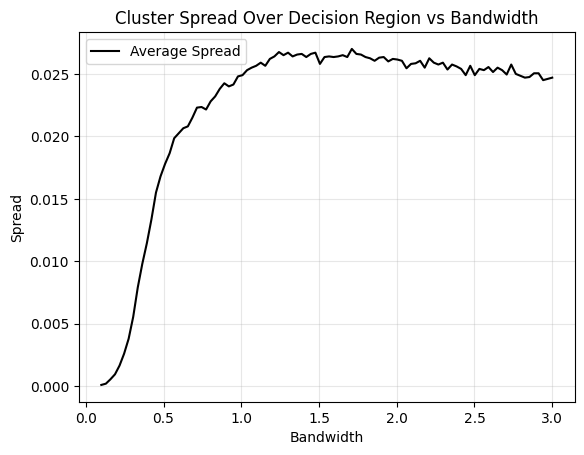

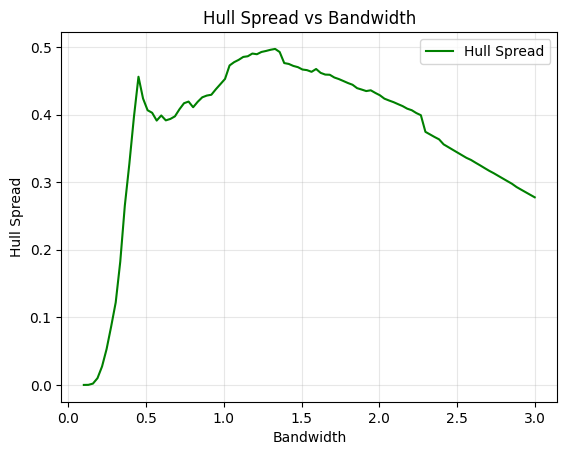

In [53]:
Qs_dict = {h: np.column_stack((Q0, Q1)) for h, Q0, Q1 in Qs}

from scipy.spatial.distance import pdist, cdist

distance_clusters = []
cluster_variances = []
avg_spreads = []
hullspreads = []

for h in Qs_dict:
  Q = Qs_dict[h]
  class0 = Q[y == 0]
  class1 = Q[y == 1]
  
  # Within-class variance (average pairwise distance)
  sum_d0, count_d0 = 0.0, 0
  if len(class0) >= 2:
    d0 = pdist(class0, 'euclidean')
    sum_d0 = d0.sum()
    count_d0 = d0.size
  
  sum_d1, count_d1 = 0.0, 0
  if len(class1) >= 2:
    d1 = pdist(class1, 'euclidean')
    sum_d1 = d1.sum()
    count_d1 = d1.size
  
  total_within = sum_d0 + sum_d1
  total_pairs = count_d0 + count_d1
  cluster_var = total_within / total_pairs if total_pairs != 0 else 0.0
  
  # Between-class distance
  avg_between = 0.0
  if len(class0) > 0 and len(class1) > 0:
    d_between = cdist(class0, class1, 'euclidean')
    avg_between = d_between.mean()

  cluster_variances.append(cluster_var)
  distance_clusters.append(avg_between)

  # Region coverage
  s = compute_spread(Q, y)
  avg_spreads.append(0.5 * (s[0] + s[1]))

  # Hull spread
  hull_spread = hullspread(Q, y)
  hullspreads.append(hull_spread)

# Plotting
plt.figure()
plt.plot(hs, distance_clusters, color='blue', label='Distance between clusters')
plt.xlabel('Bandwidth')
plt.ylabel('Average Distance')
plt.title('Distance Between Clusters vs Bandwidth')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('distance_between_clusters.png')
plt.show()

plt.figure()
plt.plot(hs, cluster_variances, color='red', label='Cluster variance')
plt.xlabel('Bandwidth')
plt.ylabel('Average Distance')
plt.title('Cluster Variance vs Bandwidth')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('cluster_variance.png')
plt.show()

plt.figure()
plt.plot(hs, avg_spreads, label='Average Spread', color='black')
plt.xlabel('Bandwidth')
plt.ylabel('Spread')
plt.title('Cluster Spread Over Decision Region vs Bandwidth')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('cluster_spread.png')
plt.show()

plt.figure()
plt.plot(hs, hullspreads, color='green', label='Hull Spread')
plt.xlabel('Bandwidth')
plt.ylabel('Hull Spread')
plt.title('Hull Spread vs Bandwidth')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('spread_vs_bandwidth.png')
plt.show()
